### IMPORTS AND SETUP

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", palette="muted")

print("Extracting physical geometry from Chen2020...")
param_virtual = pybamm.ParameterValues("Chen2020")
# Convert meters to micrometers
L_n = param_virtual["Negative electrode thickness [m]"] * 1e6
L_s = param_virtual["Separator thickness [m]"] * 1e6
L_p = param_virtual["Positive electrode thickness [m]"] * 1e6
L_total = L_n + L_s + L_p

sep_start = L_n
cat_start = L_n + L_s

print(f"Geometry: Anode={L_n:.1f}um, Separator={L_s:.1f}um, Cathode={L_p:.1f}um. Total={L_total:.1f}um")


data_na = np.load('dataset_sodium.npz')
X_na, Y_na, T_na = data_na['X'], data_na['Y'], data_na['T']
data_li = np.load('dataset_lithium.npz')
X_li, Y_li, T_li = data_li['X'], data_li['Y'], data_li['T']

N_samples = X_na.shape[0]

# Convert times to hours
T_na_hours = T_na / 3600.0
T_li_hours = T_li / 3600.0

# Lithium's anode/cathode diffusivity defaults from Chen2020 (confirmed by querying pybamm.ParameterValues("Chen2020")).
# Used below to convert Li's absolute diffusivity samples into the same "multiple of literature default" scale that sodium's k
# factors already are, so the two chemistries become comparable on column 1 and 2 again.
LI_D_ANODE_DEFAULT = 3.3e-14
LI_D_CATHODE_DEFAULT = 4e-15

Extracting physical geometry from Chen2020...
Geometry: Anode=85.2um, Separator=12.0um, Cathode=75.6um. Total=172.8um


### PARAMETER SPACE COMPARISON (KDE PLOTS)

Current (col 0) and electrolyte factor (col 3) are directly comparable as-is. Anode/cathode (col 1-2) are NOT directly comparable as lithium stores an absolute diffusivity [m2/s], while sodium stores a dimensionless scale factor on its own literature curve. Both are converted to "multiple of that chemistry's own literature default" before plotting, so the comparison stays meaningful.

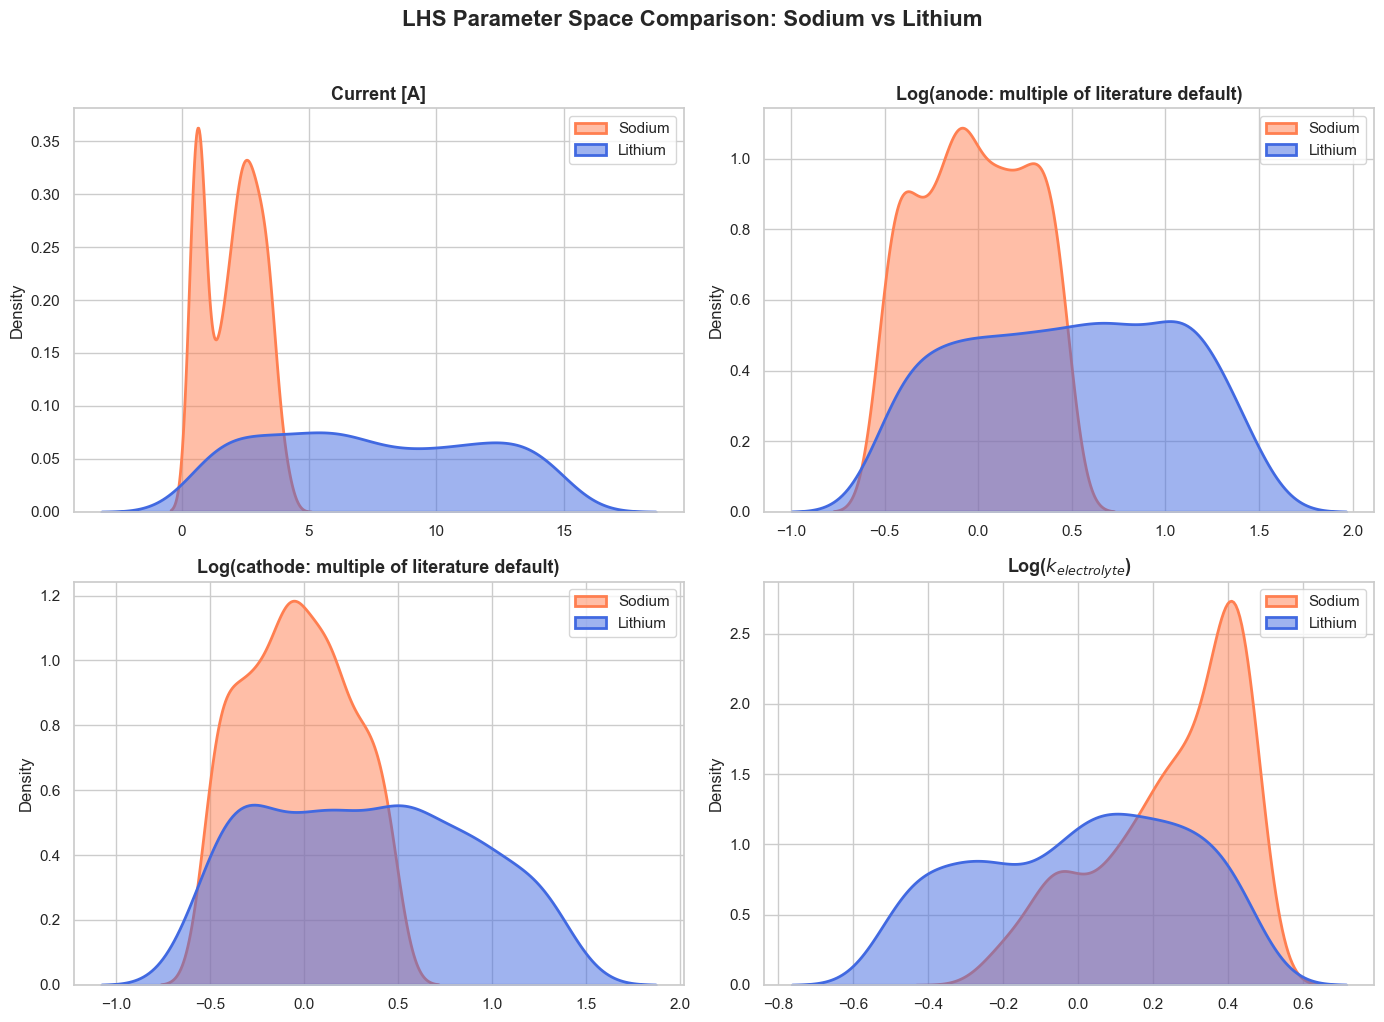

Lithium anode k-equivalent range:   0.31x - 30.23x
Sodium anode k range:               0.30x - 2.98x
Lithium cathode k-equivalent range: 0.25x - 24.77x
Sodium cathode k range:             0.30x - 2.98x


In [3]:
fig_params, axes = plt.subplots(2, 2, figsize=(14, 10))
fig_params.suptitle('LHS Parameter Space Comparison: Sodium vs Lithium', fontsize=16, fontweight='bold', y=1.02)

param_names = ['Current [A]', 'Log(anode: multiple of literature default)',
               'Log(cathode: multiple of literature default)', 'Log($k_{electrolyte}$)']

# Column 0: current, both absolute [A]
val_na_current = X_na[:, 0]
val_li_current = X_li[:, 0]

# Column 1: anode. Na is already k_anode (multiple of its own curve)
# converted to the same "multiple of literature default" basis using LI_D_ANODE_DEFAULT
val_na_anode = np.log10(X_na[:, 1])
val_li_anode = np.log10(X_li[:, 1] / LI_D_ANODE_DEFAULT)

# Column 2: cathode, same treatment as anode
val_na_cathode = np.log10(X_na[:, 2])
val_li_cathode = np.log10(X_li[:, 2] / LI_D_CATHODE_DEFAULT)

# Column 3: electrolyte. Both chemistries already store k_electrolyte (scale factor)
val_na_electrolyte = np.log10(X_na[:, 3])
val_li_electrolyte = np.log10(X_li[:, 3])

value_pairs = [
    (val_na_current, val_li_current),
    (val_na_anode, val_li_anode),
    (val_na_cathode, val_li_cathode),
    (val_na_electrolyte, val_li_electrolyte),
]

for i, (val_na, val_li) in enumerate(value_pairs):
    ax = axes[i // 2, i % 2]

    sns.kdeplot(val_na, ax=ax, fill=True, color='coral', label='Sodium', alpha=0.5, linewidth=2)
    sns.kdeplot(val_li, ax=ax, fill=True, color='royalblue', label='Lithium', alpha=0.5, linewidth=2)

    ax.set_title(param_names[i], fontsize=13, fontweight='bold')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# The anode/cathode panels above tell something the raw-magnitude comparison couldn't:
# whether each chemistry's LHS explores a comparable RANGE relative to its own literature baseline, not just comparable absolute numbers.
# Print of the actual spread to make it explicit rather than only visible by eye on the KDE plot:
print(f"Lithium anode k-equivalent range:   {(X_li[:, 1] / LI_D_ANODE_DEFAULT).min():.2f}x - {(X_li[:, 1] / LI_D_ANODE_DEFAULT).max():.2f}x")
print(f"Sodium anode k range:               {X_na[:, 1].min():.2f}x - {X_na[:, 1].max():.2f}x")
print(f"Lithium cathode k-equivalent range: {(X_li[:, 2] / LI_D_CATHODE_DEFAULT).min():.2f}x - {(X_li[:, 2] / LI_D_CATHODE_DEFAULT).max():.2f}x")
print(f"Sodium cathode k range:             {X_na[:, 2].min():.2f}x - {X_na[:, 2].max():.2f}x")

In [4]:
# Find where k_electrolyte coverage begins restricting, current by current.
import numpy as np

current_bins = np.linspace(X_na[:, 0].min(), X_na[:, 0].max(), 12)
print("Current [A]  |  n samples  |  k_electrolyte coverage range")
for lo, hi in zip(current_bins[:-1], current_bins[1:]):
    mask = (X_na[:, 0] >= lo) & (X_na[:, 0] < hi)
    if mask.sum() > 0:
        ke = X_na[mask, 3]
        print(f"[{lo:.2f}, {hi:.2f})   |  {mask.sum():4d}        |  [{ke.min():.2f}x, {ke.max():.2f}x]")

Current [A]  |  n samples  |  k_electrolyte coverage range
[0.50, 0.83)   |   135        |  [0.54x, 2.98x]
[0.83, 1.17)   |    14        |  [0.81x, 1.10x]
[1.17, 1.50)   |    26        |  [1.07x, 1.41x]
[1.50, 1.83)   |    32        |  [1.30x, 1.76x]
[1.83, 2.16)   |    41        |  [1.43x, 2.20x]
[2.16, 2.50)   |    62        |  [1.65x, 2.94x]
[2.50, 2.83)   |    54        |  [1.79x, 2.95x]
[2.83, 3.16)   |    49        |  [2.01x, 2.98x]
[3.16, 3.50)   |    47        |  [2.30x, 3.00x]
[3.50, 3.83)   |    29        |  [2.46x, 2.99x]
[3.83, 4.16)   |    10        |  [2.77x, 3.00x]


In [6]:
print(f"Maximum surviving current (sodium): {X_na[:, 0].max():.3f} A (nominal range: 0.5-5.0 A)")

Maximum surviving current (sodium): 4.162 A (nominal range: 0.5-5.0 A)


DISCHARGE TIMES

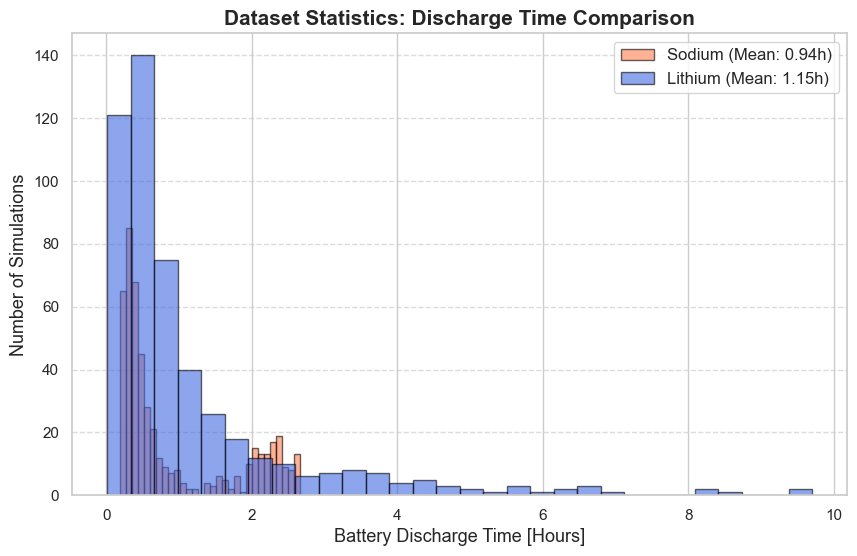

In [7]:
fig_hist, ax_hist = plt.subplots(figsize=(10, 6))

ax_hist.hist(T_na_hours, bins=30, color='coral', edgecolor='black', alpha=0.6, label=f'Sodium (Mean: {np.mean(T_na_hours):.2f}h)')
ax_hist.hist(T_li_hours, bins=30, color='royalblue', edgecolor='black', alpha=0.6, label=f'Lithium (Mean: {np.mean(T_li_hours):.2f}h)')

ax_hist.set_title('Dataset Statistics: Discharge Time Comparison', fontsize=15, fontweight='bold')
ax_hist.set_xlabel('Battery Discharge Time [Hours]', fontsize=13)
ax_hist.set_ylabel('Number of Simulations', fontsize=13)
ax_hist.legend(fontsize=12)
ax_hist.grid(True, axis='y', ls="--", alpha=0.7)

plt.show()

GLOBAL AVERAGES (Na vs Li)

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
C:\Users\angel\AppData\Local\Temp\ipykernel_7268\2345617474.py:11: SyntaxWarning: invalid escape sequence '\m'
  axes_comp[0].set_ylabel('Physical Depth [$\mu m$]', fontsize=12, fontweight='bold')


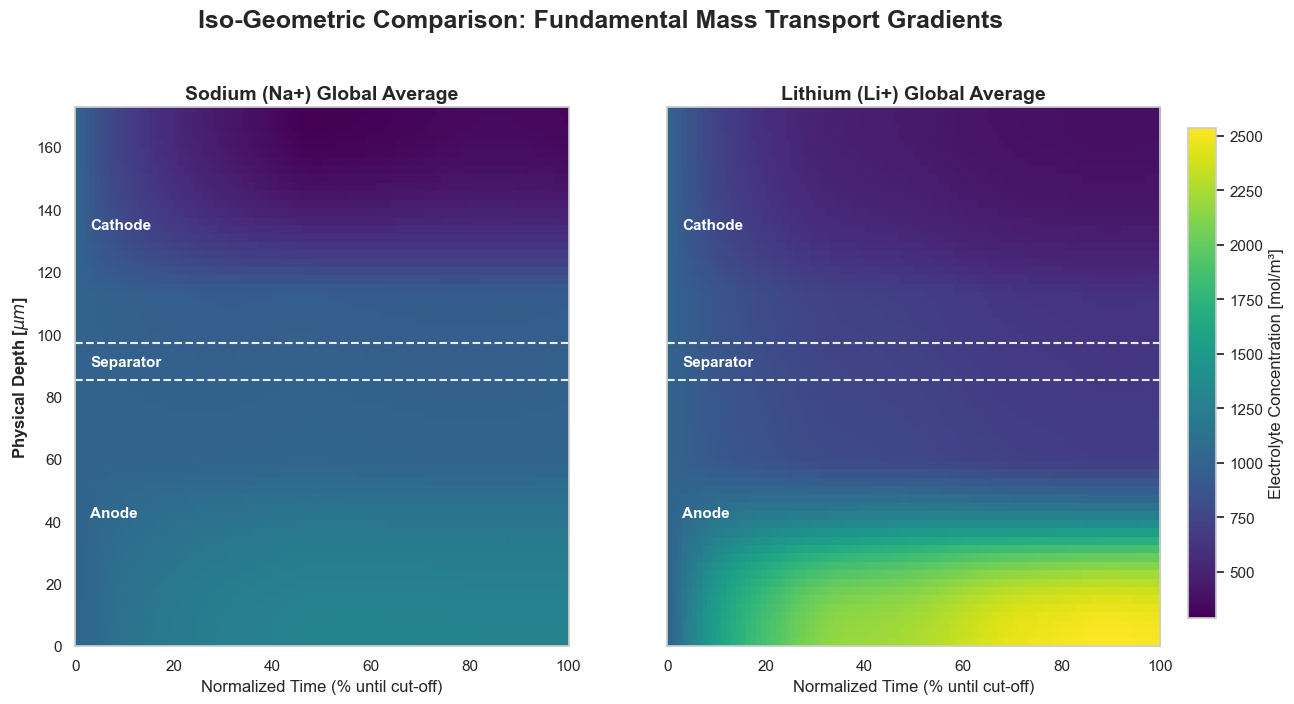

In [8]:
fig_comp, axes_comp = plt.subplots(1, 2, figsize=(14, 7))

# Calculate a universal vmin and vmax so colors mean the EXACT SAME thing in both plots
universal_vmin = min(np.min(Y_na.mean(axis=0)), np.min(Y_li.mean(axis=0)))
universal_vmax = max(np.max(Y_na.mean(axis=0)), np.max(Y_li.mean(axis=0)))

# Sodium Average
im1 = axes_comp[0].imshow(Y_na.mean(axis=0), aspect='auto', origin='lower', cmap='viridis',
                          extent=[0, 100, 0, L_total], vmin=universal_vmin, vmax=universal_vmax)
axes_comp[0].set_title('Sodium (Na+) Global Average', fontsize=14, fontweight='bold')
axes_comp[0].set_ylabel('Physical Depth [$\mu m$]', fontsize=12, fontweight='bold')

# Lithium Average
im2 = axes_comp[1].imshow(Y_li.mean(axis=0), aspect='auto', origin='lower', cmap='viridis',
                          extent=[0, 100, 0, L_total], vmin=universal_vmin, vmax=universal_vmax)
axes_comp[1].set_title('Lithium (Li+) Global Average', fontsize=14, fontweight='bold')

for ax in axes_comp:
    ax.axhline(y=sep_start, color='white', linestyle='--', linewidth=1.5, alpha=0.9)
    ax.axhline(y=cat_start, color='white', linestyle='--', linewidth=1.5, alpha=0.9)
    ax.text(3, L_n/2, 'Anode', color='white', va='center', fontweight='bold', fontsize=11)
    ax.text(3, L_n + L_s/2, 'Separator', color='white', va='center', fontweight='bold', fontsize=11)
    ax.text(3, L_n + L_s + L_p/2, 'Cathode', color='white', va='center', fontweight='bold', fontsize=11)
    ax.grid(False)
    ax.set_xlabel('Normalized Time (% until cut-off)', fontsize=12)

axes_comp[1].set_yticklabels([])

# Shared Colorbar
fig_comp.subplots_adjust(right=0.9)
cbar_ax_comp = fig_comp.add_axes([0.92, 0.15, 0.02, 0.7])
cbar_comp = fig_comp.colorbar(im1, cax=cbar_ax_comp)
cbar_comp.set_label('Electrolyte Concentration [mol/m\u00b3]', fontsize=12)

fig_comp.suptitle('Iso-Geometric Comparison: Fundamental Mass Transport Gradients', fontsize=18, fontweight='bold', y=1.02)
plt.show()